In [1]:
#this is the notebook in which i trained a cnn/vgg style model to predict different types of brani tumor 

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim

In [4]:

transform2=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
])
#defining the transforms to convert the images to tensors

In [5]:
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"

dataset = ImageFolder(root=train_dir, transform=transform2)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [6]:
class_name=dataset.classes
print(class_name)
#getting the names of the classes in the dataset

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=True)

In [8]:
transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),  #input: 1,128,128
            nn.ReLU(),
            nn.MaxPool2d(2),  #32,64,64

            nn.Conv2d(32,64,3,padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2), #64,32,32

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) #128,16,16
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,4) #4 classes here
        )
    def forward(self,x):
        x=self.net(x)
        return self.classifier(x)
model=BrainTumorCNN().to(device)


In [10]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
def train(model,loader):
    model.train()
    running_loss,correct=0.0,0
    for x,y in loader:
        x,y = x.to(device) , y.to(device)
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(out,y)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item() *x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return running_loss/len(loader.dataset),correct/len(loader.dataset)
def validate(model,loader):
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset)


In [11]:
epochs=10
for epoch in range(epochs):
    print(f"training on epoch{epoch+1}")
    train_loss,train_acc=train(model,train_loader)
    val_loss,val_acc=validate(model,val_loader)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

training on epoch1
Epoch 1: Train Loss=0.7678, Train Acc=0.6798 | Val Loss=0.5295, Val Acc=0.7498
training on epoch2
Epoch 2: Train Loss=0.4476, Train Acc=0.8341 | Val Loss=0.3810, Val Acc=0.8565
training on epoch3
Epoch 3: Train Loss=0.3215, Train Acc=0.8814 | Val Loss=0.2970, Val Acc=0.8968
training on epoch4
Epoch 4: Train Loss=0.2628, Train Acc=0.9107 | Val Loss=0.2549, Val Acc=0.9064
training on epoch5
Epoch 5: Train Loss=0.1922, Train Acc=0.9319 | Val Loss=0.2209, Val Acc=0.9178
training on epoch6
Epoch 6: Train Loss=0.1540, Train Acc=0.9453 | Val Loss=0.2757, Val Acc=0.9099
training on epoch7
Epoch 7: Train Loss=0.1049, Train Acc=0.9619 | Val Loss=0.2276, Val Acc=0.9186
training on epoch8
Epoch 8: Train Loss=0.0882, Train Acc=0.9685 | Val Loss=0.2352, Val Acc=0.9248
training on epoch9
Epoch 9: Train Loss=0.0810, Train Acc=0.9729 | Val Loss=0.1961, Val Acc=0.9388
training on epoch10
Epoch 10: Train Loss=0.0578, Train Acc=0.9781 | Val Loss=0.2584, Val Acc=0.9405


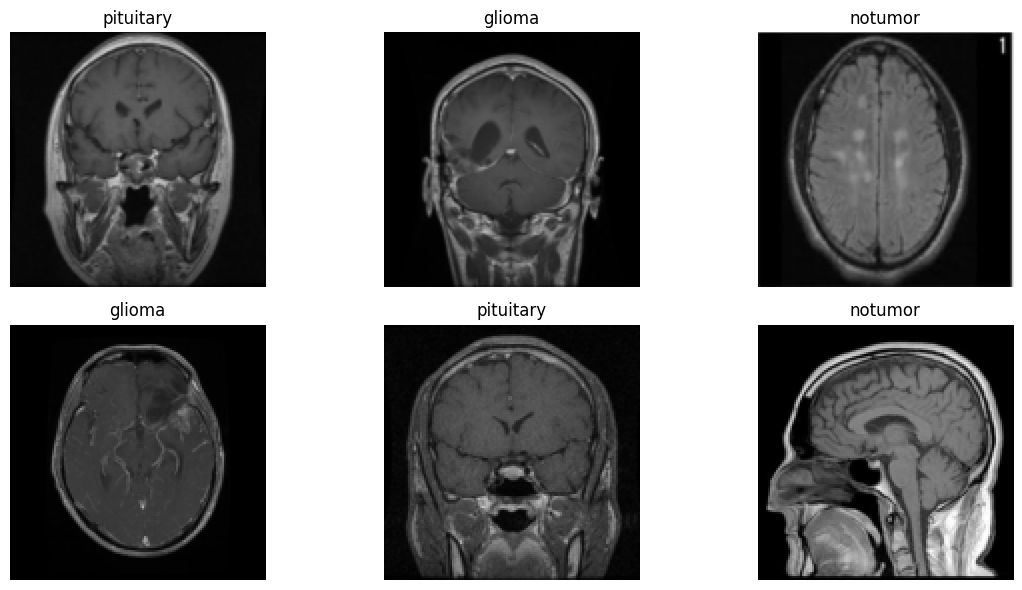

In [12]:
def denorm(img):
    return img*0.5 +0.5
class_names=dataset.classes
def show_batch():
    images, labels = next(iter(DataLoader(dataset, batch_size=16 ,shuffle =True)))
    plt.figure(figsize=(12, 6))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        img = denorm(images[i].cpu()).clamp(0, 1)  # Clamp to [0,1] after denorm
        plt.imshow(np.transpose(img.detach().numpy(), (1, 2, 0)))
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_batch()

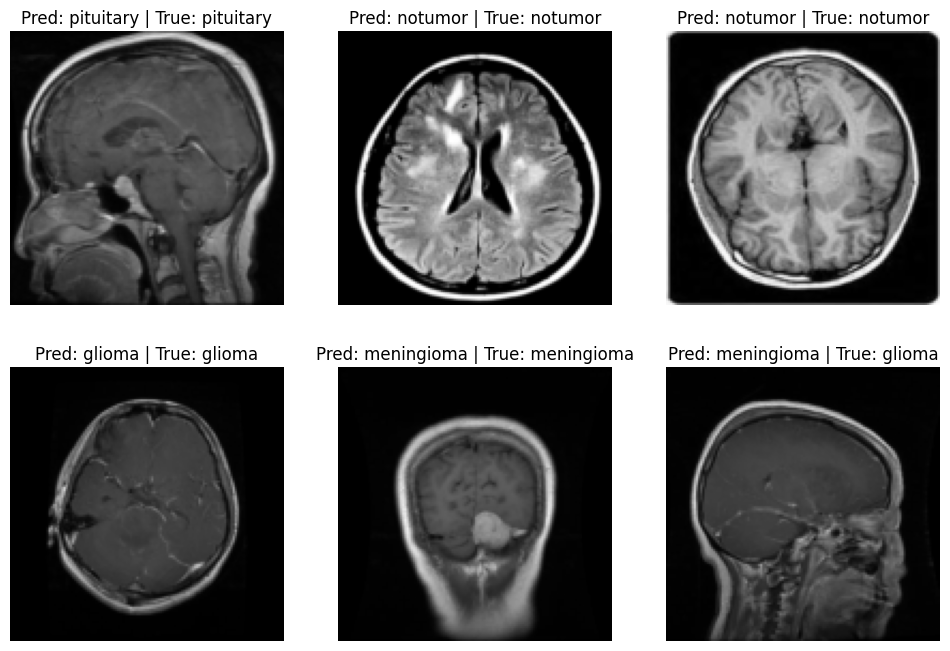

In [13]:
def predict_sample(model, loader):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    out = model(x)
    preds = torch.argmax(out, dim=1)

    plt.figure(figsize=(12, 8))
    for i in range(6):
        img = denorm(x[i].cpu())
        plt.subplot(2, 3, i+1)
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)), cmap='gray')  # Use 'gray' colormap for grayscale images
        plt.title(f"Pred: {class_names[preds[i]]} | True: {class_names[y[i]]}")
        plt.axis("off")
    plt.show()

predict_sample(model, val_loader)

In [14]:
torch.save(model.state_dict(),'/kaggle/working/model.pth')